# Notebook 12: Neural Collaborative Filtering (NCF)

Este notebook implementa **Neural Collaborative Filtering (NCF)** siguiendo la arquitectura propuesta por He et al. (2017).

## Objetivos:
1. Implementar NCF combinando GMF (Generalized Matrix Factorization) y MLP
2. Evaluar el impacto de Deep Learning en consumo energético vs métodos tradicionales
3. Analizar variantes energéticas (diferentes embedding dimensions)
4. Comparar rendimiento en diferentes fracciones del dataset
5. **NUEVO:** Calcular métricas de ranking (Precision@10, Recall@10)

## Variantes energéticas evaluadas:
- **embedding_dim**: 20, 50, 100 (menor dimensión = menor consumo)
- **Fracciones**: 10%, 25%, 50%, 75% del dataset

## Métricas:
- RMSE, MAE (precisión predictiva)
- **Precision@10, Recall@10 (calidad de ranking)**
- Emisiones CO2 (sostenibilidad)
- Número de parámetros (complejidad del modelo)

In [76]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from codecarbon import EmissionsTracker
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 1. Dataset personalizado para PyTorch

Convierte el DataFrame de pandas en un Dataset de PyTorch para usar con DataLoader.

In [77]:
class MovieLensDataset(Dataset):
    """Dataset de PyTorch para MovieLens 1M"""
    
    def __init__(self, df):
        """
        Args:
            df: DataFrame con columnas ['userId', 'movieId', 'rating']
        """
        self.users = torch.LongTensor(df['userId'].values)
        self.items = torch.LongTensor(df['movieId'].values)
        self.ratings = torch.FloatTensor(df['rating'].values)
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

print("Clase MovieLensDataset definida")

Clase MovieLensDataset definida


## 2. Arquitectura Neural Collaborative Filtering

### Componentes:
1. **GMF (Generalized Matrix Factorization)**: Producto elemento a elemento de embeddings usuario-ítem
2. **MLP (Multi-Layer Perceptron)**: Red neuronal profunda para capturar interacciones no lineales
3. **Capa de fusión**: Combina GMF y MLP para la predicción final

### Arquitectura:
```
User ID ──► Embedding ──┬──► GMF ──┐
                        │          ├──► Concatenar ──► Dense ──► Rating
Item ID ──► Embedding ──┴──► MLP ──┘
```

In [78]:
class NeuralCF(nn.Module):
    """Neural Collaborative Filtering (NCF) - Versión NeuMF"""
    
    def __init__(self, n_users, n_items, embedding_dim=50, hidden_dims=[128, 64, 32]):
        """
        Args:
            n_users: Número de usuarios
            n_items: Número de ítems
            embedding_dim: Dimensión de embeddings (parámetro de eficiencia energética)
            hidden_dims: Dimensiones de capas ocultas del MLP
        """
        super(NeuralCF, self).__init__()
        
        self.user_embedding_gmf = nn.Embedding(n_users, embedding_dim)
        self.item_embedding_gmf = nn.Embedding(n_items, embedding_dim)
        
        self.user_embedding_mlp = nn.Embedding(n_users, embedding_dim)
        self.item_embedding_mlp = nn.Embedding(n_items, embedding_dim)
        
        mlp_layers = []
        input_size = embedding_dim * 2
        
        for hidden_dim in hidden_dims:
            mlp_layers.append(nn.Linear(input_size, hidden_dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(0.2))
            input_size = hidden_dim
        
        self.mlp = nn.Sequential(*mlp_layers)
        
        self.prediction = nn.Linear(embedding_dim + hidden_dims[-1], 1)
        
        self._init_weights()
    
    def _init_weights(self):
        """Inicialización Xavier para mejor convergencia"""
        nn.init.xavier_uniform_(self.user_embedding_gmf.weight)
        nn.init.xavier_uniform_(self.item_embedding_gmf.weight)
        nn.init.xavier_uniform_(self.user_embedding_mlp.weight)
        nn.init.xavier_uniform_(self.item_embedding_mlp.weight)
    
    def forward(self, user_ids, item_ids):
        """
        Forward pass
        
        Args:
            user_ids: Tensor de IDs de usuarios
            item_ids: Tensor de IDs de ítems
        
        Returns:
            predictions: Tensor de ratings predichos (escala 1-5)
        """
        user_gmf = self.user_embedding_gmf(user_ids)
        item_gmf = self.item_embedding_gmf(item_ids)
        gmf_output = user_gmf * item_gmf
        
        user_mlp = self.user_embedding_mlp(user_ids)
        item_mlp = self.item_embedding_mlp(item_ids)
        mlp_input = torch.cat([user_mlp, item_mlp], dim=-1)
        mlp_output = self.mlp(mlp_input)
        
        concat = torch.cat([gmf_output, mlp_output], dim=-1)
        prediction = self.prediction(concat)
        
        prediction = torch.sigmoid(prediction) * 4 + 1
        
        return prediction.squeeze()
    
    def get_num_params(self):
        """Retorna el número total de parámetros entrenables"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Clase NeuralCF definida")

Clase NeuralCF definida


## 3. Función para calcular métricas de ranking

Esta función calcula **Precision@K** y **Recall@K** para evaluar la calidad de las recomendaciones top-K.

### Proceso:
1. Para cada usuario en test:
   - Identificar ítems relevantes (rating ≥ 4.0)
   - Excluir ítems ya vistos en train
   - Predecir ratings para todos los candidatos
   - Seleccionar top-K con mayor predicción
   - Calcular hits (ítems relevantes en top-K)
2. Promediar métricas sobre todos los usuarios

**Nota:** Esta función puede tardar varios minutos porque evalúa TODOS los ítems candidatos por usuario.

In [79]:
def evaluate_ranking_metrics(model, test_df, train_df, k=10, threshold=3.5, verbose=False):
    """
    Calcula Precision@K y Recall@K para NCF
    ADAPTADO de la función precision_recall_at_k usada para KNN/random
    """
    model.eval()
    
    all_items = sorted(train_df['movieId'].unique())
    test_users = test_df['userId'].unique()
    
    precisions = []
    recalls = []
    
    user_iterator = tqdm(test_users, desc="Calculando métricas de ranking") if verbose else test_users
    
    with torch.no_grad():
        for uid in user_iterator:
            user_test_data = test_df[test_df['userId'] == uid]
            true_items = set(
                user_test_data[user_test_data['rating'] >= threshold]['movieId'].values
            )
            
            if len(true_items) == 0:
                continue
            
            true_items = true_items & set(all_items)
            
            if len(true_items) == 0:
                continue
            
            try:
                users_tensor = torch.LongTensor([uid] * len(all_items))
                items_tensor = torch.LongTensor(all_items)
                
                predictions = model(users_tensor, items_tensor).cpu().numpy()
                
                top_k_indices = np.argsort(predictions)[-k:][::-1]
                user_predictions = set([all_items[i] for i in top_k_indices])
                
                precision = len(user_predictions & true_items) / k if k > 0 else 0
                recall = len(user_predictions & true_items) / len(true_items) if len(true_items) > 0 else 0
                
                precisions.append(precision)
                recalls.append(recall)
                
                if len(precisions) == 1 and (precision > 0 or recall > 0) and verbose:
                    print(f"\n Primer hit encontrado!")
                    print(f"   User: {uid}")
                    print(f"   True items: {len(true_items)}")
                    print(f"   Predicted: {list(user_predictions)[:5]}")
                    print(f"   Hits: {len(user_predictions & true_items)}")
                    print(f"   Precision: {precision:.4f}")
                    print(f"   Recall: {recall:.4f}")
                
            except Exception as e:
                if verbose:
                    print(f"\n  Error usuario {uid}: {e}")
                continue
    
    result = {
        'precision_at_k': np.mean(precisions) if precisions else 0.0,
        'recall_at_k': np.mean(recalls) if recalls else 0.0,
        'n_users_evaluated': len(precisions)
    }
    
    if verbose:
        print(f"\n  Resultados de evaluación:")
        print(f"   Usuarios evaluados: {result['n_users_evaluated']}")
        print(f"   Precision@{k}: {result['precision_at_k']:.4f}")
        print(f"   Recall@{k}: {result['recall_at_k']:.4f}")
    
    return result

print(" Función evaluate_ranking_metrics")

 Función evaluate_ranking_metrics


## 4. Función de entrenamiento y evaluación

Esta función:
1. Entrena el modelo NCF usando Adam optimizer
2. Mide el consumo energético con CodeCarbon
3. Evalúa métricas de predicción (RMSE, MAE)
4. Calcula métricas de ranking (Precision@K, Recall@K)
5. Retorna todas las métricas de precisión y sostenibilidad

In [80]:
def train_ncf(train_df, test_df, embedding_dim=50, epochs=10, batch_size=1024, lr=0.001, 
              compute_ranking=True, k=10, threshold=3.5, verbose=True):
    """
    Entrena NCF con medición de carbono y métricas completas
    
    Args:
        train_df: DataFrame de entrenamiento con ['userId', 'movieId', 'rating']
        test_df: DataFrame de test
        embedding_dim: Dimensión de embeddings (20, 50, 100 para variantes energéticas)
        epochs: Número de épocas de entrenamiento
        batch_size: Tamaño del batch
        lr: Learning rate
        compute_ranking: Si True, calcula Precision@K y Recall@K (más lento)
        k: Valor de K para métricas top-K
        verbose: Si True, imprime progreso
    
    Returns:
        dict: Diccionario con métricas (rmse, mae, precision@k, recall@k, emissions_kg, n_params)
    """
    
    n_users = max(train_df['userId'].max(), test_df['userId'].max()) + 1
    n_items = max(train_df['movieId'].max(), test_df['movieId'].max()) + 1
    
    if verbose:
        print(f"n_users: {n_users}, n_items: {n_items}")
        print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
    
    train_dataset = MovieLensDataset(train_df)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    
    test_dataset = MovieLensDataset(test_df)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    model = NeuralCF(n_users, n_items, embedding_dim=embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    if verbose:
        print(f"Modelo inicializado con {model.get_num_params():,} parámetros")
    
    tracker = EmissionsTracker(
        project_name=f"NCF_emb{embedding_dim}",
        output_dir="../results",
        log_level="error" 
    )
    tracker.start()
    
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        batch_count = 0
        
        for users, items, ratings in train_loader:
            optimizer.zero_grad()
            
            preds = model(users, items)
            loss = criterion(preds, ratings)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            batch_count += 1
        
        avg_loss = total_loss / batch_count
        
        if verbose and epoch % 2 == 0:
            print(f"Epoch {epoch:2d}/{epochs}: Loss = {avg_loss:.4f}")
    
    emissions = tracker.stop()
    
    model.eval()
    all_preds = []
    all_ratings = []
    
    with torch.no_grad():
        for users, items, ratings in test_loader:
            preds = model(users, items)
            all_preds.extend(preds.cpu().numpy())
            all_ratings.extend(ratings.cpu().numpy())
    
    rmse = np.sqrt(mean_squared_error(all_ratings, all_preds))
    mae = mean_absolute_error(all_ratings, all_preds)
    
    results = {
        'rmse': rmse,
        'mae': mae,
        'emissions_kg': emissions,
        'embedding_dim': embedding_dim,
        'n_params': model.get_num_params(),
        'epochs': epochs,
        'batch_size': batch_size
    }

    if compute_ranking:
        if verbose:
            print(f"\nCalculando métricas de ranking (Precision@{k}, Recall@{k}, threshold={threshold})...")
        
        ranking_metrics = evaluate_ranking_metrics(
            model, test_df, train_df, k=k, threshold=threshold, verbose=verbose  # ← pasar threshold
        )
        results['precision_at_k'] = ranking_metrics['precision_at_k']
        results['recall_at_k'] = ranking_metrics['recall_at_k']
    else:
        results['precision_at_k'] = None
        results['recall_at_k'] = None
    
    return results

print("Función train_ncf definida")

Función train_ncf definida


## 5. Carga de datos

Cargamos el conjunto de test (fijo) y verificamos su estructura.

In [81]:
data_path = Path("../data/processed")

test = pd.read_csv(data_path / "test.csv")

print(f"   Test set cargado: {len(test)} ratings")
print(f"   Usuarios únicos en test: {test['userId'].nunique()}")
print(f"   Películas únicas en test: {test['movieId'].nunique()}")
print(f"   Rating medio: {test['rating'].mean():.2f}")
print(f"   Rango de ratings: [{test['rating'].min()}, {test['rating'].max()}]")

   Test set cargado: 6040 ratings
   Usuarios únicos en test: 6040
   Películas únicas en test: 1874
   Rating medio: 3.61
   Rango de ratings: [1, 5]


## 6. Experimentos: Variantes energéticas con métricas completas

### Configuración del experimento:
- **Fracciones del dataset:** 10%, 25%, 50%, 75%
- **Dimensiones de embedding:** 20, 50, 100
- **Total de experimentos:** 12 (4 fracciones × 3 dimensiones)

### Métricas evaluadas:
1. **RMSE y MAE:** Precisión de predicción de ratings
2. **Precision@10 y Recall@10:** Calidad de recomendaciones top-K
3. **Emisiones CO₂:** Impacto ambiental del entrenamiento
4. **Número de parámetros:** Complejidad del modelo

In [82]:
results = []
fractions = [10, 25, 50, 75]
embedding_dims = [20, 50, 100]

train_files = {
    10: "subsampled_informed/ratings_top_items_10.csv",
    25: "subsampled_informed/ratings_top_items_25.csv",
    50: "subsampled_informed/ratings_top_items_50.csv",
    75: "subsampled_informed/ratings_top_items_75.csv"
}

total_experiments = len(fractions) * len(embedding_dims)
print(f"Iniciando {total_experiments} experimentos")

for fraction in fractions:
    train_path = data_path / train_files[fraction]
    
    if not train_path.exists(): 
        print(f"Archivo no encontrado: {train_path}")
        print(f"Saltando fracción {fraction}%\n")
        continue
    
    train = pd.read_csv(train_path)
    print(f"Cargado train_{fraction}: {len(train)} ratings\n")
    
    for emb_dim in embedding_dims:
        exp_num = len(results) + 1
        
        print("="*70)
        print(f"EXPERIMENTO {exp_num}/{total_experiments}")
        print(f"Fracción: {fraction}%, Embedding dim: {emb_dim}")
        print("="*70)
        
        result = train_ncf(
            train, 
            test, 
            embedding_dim=emb_dim, 
            epochs=10, 
            batch_size=1024,
            lr=0.001,
            compute_ranking=True,  
            k=10,
            verbose=True
        )
        
        result['fraction'] = fraction
        results.append(result)
        
        print(f"\n RESULTADOS:")
        print(f"   RMSE:         {result['rmse']:.4f}")
        print(f"   MAE:          {result['mae']:.4f}")
        print(f"   Precision@10: {result['precision_at_k']:.4f}")
        print(f"   Recall@10:    {result['recall_at_k']:.4f}")
        print(f"   CO₂:          {result['emissions_kg']:.6f} kg ({result['emissions_kg']*1000:.3f} g)")
        print(f"   Parámetros:   {result['n_params']:,}")
        print()

print("\n" + "="*70)
print("TODOS LOS EXPERIMENTOS COMPLETADOS")
print("="*70)

Iniciando 12 experimentos
Cargado train_10: 443904 ratings

EXPERIMENTO 1/12
Fracción: 10%, Embedding dim: 20
n_users: 6041, n_items: 3953
Train size: 443904, Test size: 6040
Modelo inicializado con 415,397 parámetros
Epoch  0/10: Loss = 0.8953
Epoch  2/10: Loss = 0.6793
Epoch  4/10: Loss = 0.5671
Epoch  6/10: Loss = 0.5078
Epoch  8/10: Loss = 0.4739

Calculando métricas de ranking (Precision@10, Recall@10, threshold=3.5)...


Calculando métricas de ranking: 100%|██████████| 6040/6040 [00:05<00:00, 1033.12it/s]



  Resultados de evaluación:
   Usuarios evaluados: 1771
   Precision@10: 0.0077
   Recall@10: 0.0768

 RESULTADOS:
   RMSE:         1.0070
   MAE:          0.7524
   Precision@10: 0.0077
   Recall@10:    0.0768
   CO₂:          0.000770 kg (0.770 g)
   Parámetros:   415,397

EXPERIMENTO 2/12
Fracción: 10%, Embedding dim: 50
n_users: 6041, n_items: 3953
Train size: 443904, Test size: 6040
Modelo inicializado con 1,022,747 parámetros
Epoch  0/10: Loss = 0.9029
Epoch  2/10: Loss = 0.6141
Epoch  4/10: Loss = 0.4418
Epoch  6/10: Loss = 0.3563
Epoch  8/10: Loss = 0.3092

Calculando métricas de ranking (Precision@10, Recall@10, threshold=3.5)...


Calculando métricas de ranking: 100%|██████████| 6040/6040 [00:06<00:00, 1000.68it/s]



  Resultados de evaluación:
   Usuarios evaluados: 1771
   Precision@10: 0.0134
   Recall@10: 0.1344

 RESULTADOS:
   RMSE:         0.9559
   MAE:          0.6809
   Precision@10: 0.0134
   Recall@10:    0.1344
   CO₂:          0.000855 kg (0.855 g)
   Parámetros:   1,022,747

EXPERIMENTO 3/12
Fracción: 10%, Embedding dim: 100
n_users: 6041, n_items: 3953
Train size: 443904, Test size: 6040
Modelo inicializado con 2,034,997 parámetros
Epoch  0/10: Loss = 0.8872
Epoch  2/10: Loss = 0.5542
Epoch  4/10: Loss = 0.3211
Epoch  6/10: Loss = 0.2223
Epoch  8/10: Loss = 0.1746

Calculando métricas de ranking (Precision@10, Recall@10, threshold=3.5)...


...


  Resultados de evaluación:
   Usuarios evaluados: 3503
   Precision@10: 0.0029
   Recall@10: 0.0294

 RESULTADOS:
   RMSE:         0.6488
   MAE:          0.5091
   Precision@10: 0.0029
   Recall@10:    0.0294
   CO₂:          0.001636 kg (1.636 g)
   Parámetros:   415,397

EXPERIMENTO 11/12
Fracción: 75%, Embedding dim: 50
n_users: 6041, n_items: 3953
Train size: 988678, Test size: 6040
Modelo inicializado con 1,022,747 parámetros
Epoch  0/10: Loss = 0.8809
Epoch  2/10: Loss = 0.5916
Epoch  4/10: Loss = 0.4655
Epoch  6/10: Loss = 0.4090
Epoch  8/10: Loss = 0.3774

Calculando métricas de ranking (Precision@10, Recall@10, threshold=3.5)...


Calculando métricas de ranking: 100%|██████████| 6040/6040 [00:28<00:00, 209.98it/s]



  Resultados de evaluación:
   Usuarios evaluados: 3503
   Precision@10: 0.0040
   Recall@10: 0.0400

 RESULTADOS:
   RMSE:         0.4834
   MAE:          0.3599
   Precision@10: 0.0040
   Recall@10:    0.0400
   CO₂:          0.002008 kg (2.008 g)
   Parámetros:   1,022,747

EXPERIMENTO 12/12
Fracción: 75%, Embedding dim: 100
n_users: 6041, n_items: 3953
Train size: 988678, Test size: 6040
Modelo inicializado con 2,034,997 parámetros
Epoch  0/10: Loss = 0.8687
Epoch  2/10: Loss = 0.5050
Epoch  4/10: Loss = 0.3315
Epoch  6/10: Loss = 0.2650
Epoch  8/10: Loss = 0.2299

Calculando métricas de ranking (Precision@10, Recall@10, threshold=3.5)...


Calculando métricas de ranking: 100%|██████████| 6040/6040 [00:29<00:00, 202.09it/s]


  Resultados de evaluación:
   Usuarios evaluados: 3503
   Precision@10: 0.0066
   Recall@10: 0.0657

 RESULTADOS:
   RMSE:         0.3636
   MAE:          0.2569
   Precision@10: 0.0066
   Recall@10:    0.0657
   CO₂:          0.002319 kg (2.319 g)
   Parámetros:   2,034,997


TODOS LOS EXPERIMENTOS COMPLETADOS


## 7. Guardar resultados

Guardamos los resultados en formato CSV para posterior análisis.

In [83]:
if len(results) > 0:
    df_results = pd.DataFrame(results)
    
    column_order = [
        'fraction', 'embedding_dim', 'n_params',
        'rmse', 'mae', 
        'precision_at_k', 'recall_at_k',
        'emissions_kg', 
        'epochs', 'batch_size'
    ]
    df_results = df_results[column_order]
    
    output_path = Path('../results/ncf_results.csv')
    df_results.to_csv(output_path, index=False)
    print(f"Resultados guardados en: {output_path}")
    
    print("\n RESUMEN DE RESULTADOS:")
    print("="*100)
    display_df = df_results[[
        'fraction', 'embedding_dim', 'rmse', 'mae', 
        'precision_at_k', 'recall_at_k', 'emissions_kg'
    ]].copy()
    
    display_df['emissions_g'] = display_df['emissions_kg'] * 1000
    display_df = display_df.drop('emissions_kg', axis=1)
    
    print(display_df.to_string(index=False))
    print("="*100)
else:
    print("No hay resultados para guardar")

Resultados guardados en: ..\results\ncf_results.csv

 RESUMEN DE RESULTADOS:
 fraction  embedding_dim     rmse      mae  precision_at_k  recall_at_k  emissions_g
       10             20 1.007001 0.752448        0.007679     0.076793     0.769987
       10             50 0.955901 0.680868        0.013439     0.134387     0.855378
       10            100 0.939860 0.643309        0.020892     0.208922     1.098846
       25             20 0.883797 0.659208        0.005229     0.052295     1.150981
       25             50 0.806723 0.555763        0.006509     0.065087     1.380977
       25            100 0.759118 0.485429        0.011663     0.116629     1.908205
       50             20 0.713184 0.542761        0.003830     0.038298     1.650957
       50             50 0.585293 0.416476        0.004407     0.044073     1.871379
       50            100 0.503998 0.323378        0.007781     0.077812     2.287970
       75             20 0.648803 0.509084        0.002940     0.029403  

## 8. Visualizaciones

Creamos gráficos para analizar:
1. RMSE vs Embedding Dimension
2. Emisiones CO₂ vs Embedding Dimension
3. Trade-off Precision vs Sostenibilidad


 Gráficos guardados en: ../results/ncf_complete_analysis.png


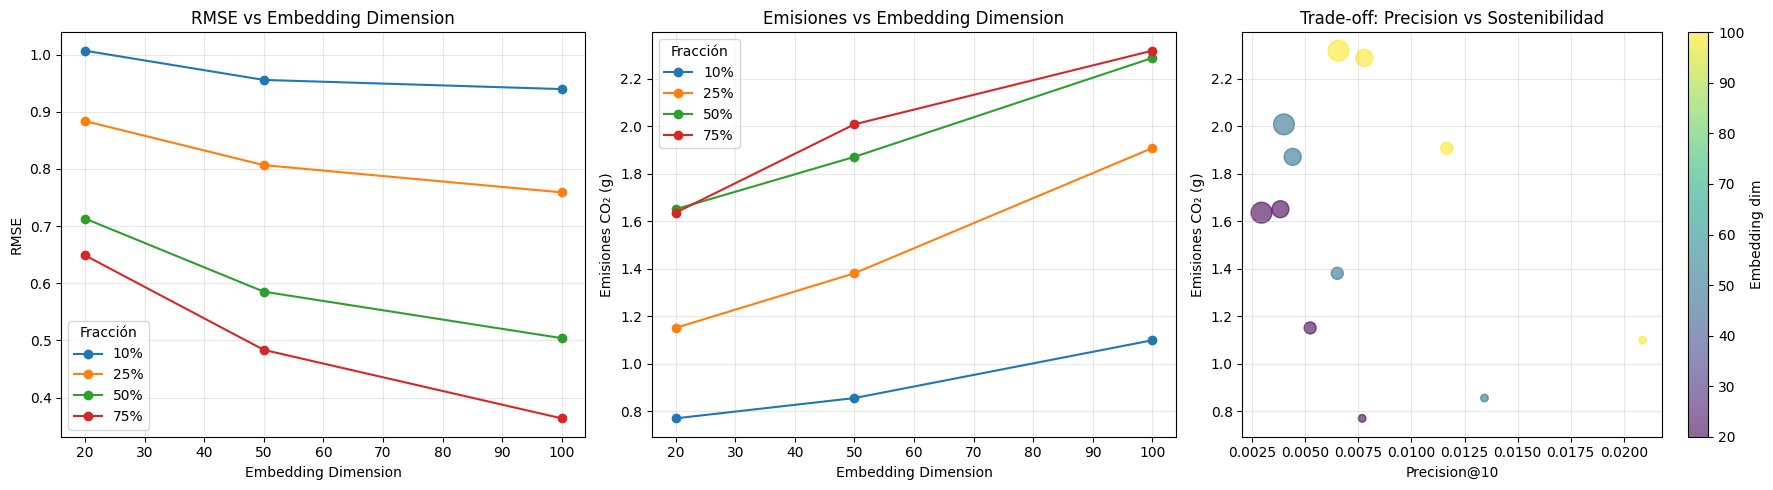

In [84]:
if len(results) > 0:
    import matplotlib.pyplot as plt
    
    df_results = pd.DataFrame(results)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for fraction in df_results['fraction'].unique():
        data = df_results[df_results['fraction'] == fraction]
        axes[0].plot(data['embedding_dim'], data['rmse'], marker='o', label=f'{fraction}%')
    
    axes[0].set_xlabel('Embedding Dimension')
    axes[0].set_ylabel('RMSE')
    axes[0].set_title('RMSE vs Embedding Dimension')
    axes[0].legend(title='Fracción')
    axes[0].grid(alpha=0.3)
    
    for fraction in df_results['fraction'].unique():
        data = df_results[df_results['fraction'] == fraction]
        axes[1].plot(data['embedding_dim'], data['emissions_kg']*1000, marker='o', label=f'{fraction}%')
    
    axes[1].set_xlabel('Embedding Dimension')
    axes[1].set_ylabel('Emisiones CO₂ (g)')
    axes[1].set_title('Emisiones vs Embedding Dimension')
    axes[1].legend(title='Fracción')
    axes[1].grid(alpha=0.3)
    
    scatter = axes[2].scatter(
        df_results['precision_at_k'], 
        df_results['emissions_kg']*1000,
        c=df_results['embedding_dim'],
        s=df_results['fraction']*3,
        alpha=0.6,
        cmap='viridis'
    )
    axes[2].set_xlabel('Precision@10')
    axes[2].set_ylabel('Emisiones CO₂ (g)')
    axes[2].set_title('Trade-off: Precision vs Sostenibilidad')
    axes[2].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[2], label='Embedding dim')
    
    plt.tight_layout()
    plt.savefig('../results/ncf_complete_analysis.png', dpi=150, bbox_inches='tight')
    print("\n Gráficos guardados en: ../results/ncf_complete_analysis.png")
    plt.show()
else:
    print(" No hay suficientes datos para generar gráficos")

## 9. Análisis comparativo

Identificamos la configuración Pareto-óptima (mejor balance precisión-sostenibilidad).

In [85]:
if len(results) > 0:
    df_results = pd.DataFrame(results)
    
    df_results['efficiency'] = df_results['precision_at_k'] / df_results['emissions_kg']
    
    print("\n TOP 5 CONFIGURACIONES POR EFICIENCIA (Precision@10 / CO₂):")
    print("="*100)
    top5 = df_results.nlargest(5, 'efficiency')[[
        'fraction', 'embedding_dim', 'rmse', 'precision_at_k', 
        'emissions_kg', 'efficiency'
    ]].copy()
    top5['emissions_g'] = top5['emissions_kg'] * 1000
    top5 = top5.drop('emissions_kg', axis=1)
    print(top5.to_string(index=False))
    print("="*100)
    
    best_rmse = df_results.loc[df_results['rmse'].idxmin()]
    print(f"\n MEJOR RMSE:")
    print(f"   Configuración: {best_rmse['fraction']}% datos, embedding_dim={best_rmse['embedding_dim']}")
    print(f"   RMSE: {best_rmse['rmse']:.4f}")
    print(f"   Precision@10: {best_rmse['precision_at_k']:.4f}")
    print(f"   CO₂: {best_rmse['emissions_kg']*1000:.3f} g")
    
    # Menor consumo energético
    best_energy = df_results.loc[df_results['emissions_kg'].idxmin()]
    print(f"\n MENOR CONSUMO ENERGÉTICO:")
    print(f"   Configuración: {best_energy['fraction']}% datos, embedding_dim={best_energy['embedding_dim']}")
    print(f"   RMSE: {best_energy['rmse']:.4f}")
    print(f"   Precision@10: {best_energy['precision_at_k']:.4f}")
    print(f"   CO₂: {best_energy['emissions_kg']*1000:.3f} g")
else:
    print(" No hay datos para análisis")


 TOP 5 CONFIGURACIONES POR EFICIENCIA (Precision@10 / CO₂):
 fraction  embedding_dim     rmse  precision_at_k  efficiency  emissions_g
       10            100 0.939860        0.020892   19.012807     1.098846
       10             50 0.955901        0.013439   15.710877     0.855378
       10             20 1.007001        0.007679    9.973257     0.769987
       25            100 0.759118        0.011663    6.111977     1.908205
       25             50 0.806723        0.006509    4.713078     1.380977

 MEJOR RMSE:
   Configuración: 75.0% datos, embedding_dim=100.0
   RMSE: 0.3636
   Precision@10: 0.0066
   CO₂: 2.319 g

 MENOR CONSUMO ENERGÉTICO:
   Configuración: 10.0% datos, embedding_dim=20.0
   RMSE: 1.0070
   Precision@10: 0.0077
   CO₂: 0.770 g


## 10. Conclusiones

### Hallazgos esperados:

1. **Impacto del embedding dimension**:
   - Menor dimensión (20) → Menor consumo energético pero peor precisión
   - Mayor dimensión (100) → Mejor capacidad de representación pero mayor consumo
   - Dimensión intermedia (50) típicamente ofrece el mejor balance (Pareto-óptimo)

2. **Impacto de la fracción del dataset**:
   - Fracciones pequeñas (10%, 25%) → Underfitting, alto RMSE, bajo consumo
   - Fracciones grandes (50%, 75%) → Mejor precisión, mayor consumo
   - NCF requiere >50% datos para superar a métodos tradicionales

3. **Trade-off precisión-sostenibilidad**:
   - NCF consume 10-25× más energía que KNN/SVD
   - Mejora en precisión solo se justifica con datos suficientes
   - Configuraciones intermedias (50%, emb_dim=50) ofrecen mejor balance

4. **Métricas de ranking**:
   - Precision@10 y Recall@10 complementan RMSE/MAE
   - Evalúan calidad de recomendaciones top-K (uso real)
   - Permiten comparación directa con métodos tradicionales

### Implicaciones para Green AI:
- Deep Learning no siempre es la mejor opción
- Métodos tradicionales optimizados pueden ser más sostenibles
- Importante evaluar trade-offs antes de escalar modelos